# Generación de Conjuntos de Datos
## (Hechos a la medida)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Funciones

In [2]:
def generate_binary_classification_dataset(
    n_samples=1000,
    n_features=2,
    class_distance=4.0,
    base_std=0.8,
    boundary_noise=0.2,
    feature_noise=0.0,
    direction=None,          # None | array-like shape (n_features,)
    theta=None,              # Only for 2D
    theta_degrees=False,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    if n_features < 2:
        raise ValueError("n_features must be >= 2")

    # Direction selection / control
    if theta is not None:
        if n_features != 2:
            raise ValueError("theta can only be used when n_features == 2")
        ang = np.deg2rad(theta) if theta_degrees else float(theta)
        direction_vec = np.array([np.cos(ang), np.sin(ang)], dtype=float)
    elif direction is not None:
        direction_vec = np.array(direction, dtype=float).reshape(-1)
        if direction_vec.shape[0] != n_features:
            raise ValueError("direction must have length n_features")
    else:
        direction_vec = rng.normal(size=n_features)

    norm = np.linalg.norm(direction_vec)
    if norm == 0:
        raise ValueError("direction vector must be non-zero")
    direction_vec = direction_vec / norm

    # Class sizes
    n0 = n_samples // 2
    n1 = n_samples - n0

    # Class centers
    center0 = -direction_vec * (class_distance / 2.0)
    center1 =  direction_vec * (class_distance / 2.0)

    # Base clouds
    X0 = rng.normal(scale=base_std, size=(n0, n_features)) + center0
    X1 = rng.normal(scale=base_std, size=(n1, n_features)) + center1

    # Boundary thickness: noise along the separating direction
    d = direction_vec.reshape(1, -1)
    X0 += rng.normal(scale=boundary_noise, size=(n0, 1)) * d
    X1 += rng.normal(scale=boundary_noise, size=(n1, 1)) * d

    # Global feature noise
    if feature_noise > 0:
        X0 += rng.normal(scale=feature_noise, size=X0.shape)
        X1 += rng.normal(scale=feature_noise, size=X1.shape)

    X = np.vstack([X0, X1])
    y = np.array([0]*n0 + [1]*n1)

    cols = [f"x{i+1}" for i in range(n_features)]
    df = pd.DataFrame(X, columns=cols)
    df["y"] = y

    return df

In [3]:
def plot_classification_dataset(
    df,
    target_col="y",
    dims=2,
    elev=25,      # vertical viewing angle
    azim=45       # horizontal rotation angle
):
    """
    Plots a binary classification dataset in 2D or 3D.
    Allows camera angle control in 3D.
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if dims == 2:
        if X.shape[1] < 2:
            raise ValueError("Dataset must have at least 2 features for 2D plot.")

        plt.figure(figsize=(8,6))

        for label in sorted(y.unique()):
            subset = df[df[target_col] == label]
            plt.scatter(
                subset.iloc[:,0],
                subset.iloc[:,1],
                label=f"class {label}",
                alpha=0.7
            )

        plt.xlabel(X.columns[0])
        plt.ylabel(X.columns[1])
        plt.title("Binary Classification Dataset (2D)")
        plt.legend()
        plt.grid(True)
        plt.show()


    elif dims == 3:
        if X.shape[1] < 3:
            raise ValueError("Dataset must have at least 3 features for 3D plot.")

        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')

        for label in sorted(y.unique()):
            subset = df[df[target_col] == label]
            ax.scatter(
                subset.iloc[:,0],
                subset.iloc[:,1],
                subset.iloc[:,2],
                label=f"class {label}",
                alpha=0.7
            )

        ax.set_xlabel(X.columns[0])
        ax.set_ylabel(X.columns[1])
        ax.set_zlabel(X.columns[2])
        ax.set_title("Binary Classification Dataset (3D)")
        ax.legend()

        # Camera orientation
        ax.view_init(elev=elev, azim=azim)

        plt.show()

    else:
        raise ValueError("dims must be either 2 or 3")

## Datos Generados

### Datos Linealmente Separables

In [8]:
# Df en 3 dimensiones y 10 000 muestras
df_1 = generate_binary_classification_dataset(
    n_samples=10000,
    n_features=3,
    class_distance=7.0,
    base_std=0.8,
    boundary_noise=0.2,
    feature_noise=0.0,
    theta=None,              # 30 grados
    theta_degrees=True,
    random_state=42 # Semilla
)
df_1.head()

,x1,x2,x3,y
0,-0.089699,1.313391,-3.115777,0
1,-0.718095,2.546880,-2.033826,0
2,-1.511018,3.531431,-1.418384,0
3,-0.722646,3.548436,-1.535807,0
4,-1.530624,3.172766,-2.843698,0


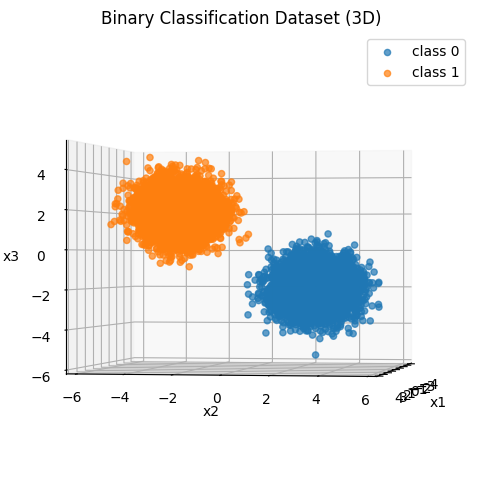

In [10]:
# Graficando dataset 1
plot_classification_dataset(df_1, target_col="y", dims=3, elev=0, azim=10)

In [11]:
# Guardando DF1
df_1.to_csv("../data/mocked_data/binary_classification_separable_3d.csv", index=False)

### Datos no completamente separables

In [12]:
# Df en 2 dimensiones y 20 000 muestras
df_2 = generate_binary_classification_dataset(
    n_samples=20000,
    n_features=3,
    class_distance=4.0,
    base_std=0.8,
    boundary_noise=0.2,
    feature_noise=0.0,
    theta=None,              # 30 grados
    theta_degrees=True,
    random_state=42
)
df_2.head()

,x1,x2,x3,y
0,0.243460,0.176335,-2.295278,0
1,-0.437769,1.590139,-1.343443,0
2,-1.233956,2.585832,-0.736042,0
3,-0.372753,2.354267,-0.674096,0
4,-1.181945,1.982743,-1.984979,0


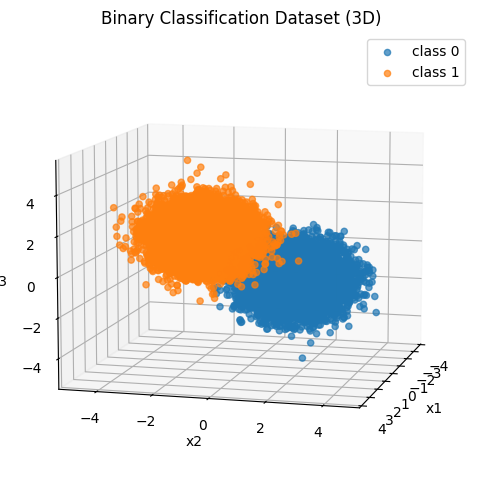

In [17]:
# Graficando dataset 2
plot_classification_dataset(df_2, target_col="y", dims=3, elev=10, azim=15)

In [19]:
# Guardando DF2
df_2.to_csv("../data/mocked_data/binary_classification_less_separable_3d.csv", index=False)